In [22]:
# Based on simulation 1: create a simulation where the RCT is not included in the observational study in 
# terms of X and show performance of the model

import numpy as np
import pandas as pd
from scipy.stats import bernoulli, norm

def data_simulation(sample_size_rct, sample_size_obs):
    """
    Simulate observational and trial data according to a specified logistic participation model.\
    

        Confounding: Complex
        Y(0): Complex
        Y(1): Complex
        CATE: Complex


    Parameters:
    sample_size : int
        Number of samples to generate.
    beta0 : float
        Intercept parameter of the logistic participation model.
    beta1 : float
        Slope parameter of the logistic participation model.

    Returns:
    data_trial : numpy.ndarray
        Simulated trial data containing columns for participation indicator (S), covariate (X), treatment assignment (A), and outcome (Y).
    data_observation : numpy.ndarray
        Simulated observational data containing columns for participation indicator (S), covariate (X), treatment assignment (A), and outcome (Y).
    """

    

    X_trial = np.random.uniform(-4, 0, sample_size_rct)
    S_trial = np.ones(X_trial.shape[0])
    
    A_trial = bernoulli.rvs(0.5, size=np.shape(X_trial)[0])
    tau_X_trial = 1 + X_trial + X_trial**2
    epsilon_trial = norm.rvs(0, 1.0, np.shape(X_trial)[0])
    Y_trial = A_trial * tau_X_trial + X_trial**2 - 1 + epsilon_trial

    X_observational = np.random.uniform(-2, 4, sample_size_obs)
    S_observational = np.zeros(X_observational.shape[0])
    logit_e_X_0 = X_observational
    A_observational = bernoulli.rvs(1 / (1 + np.exp(-logit_e_X_0)), size=np.shape(X_observational)[0])
    tau_X_observational = 1 + X_observational + X_observational**2
    U_observational = (2 * A_observational - 1) *np.sin(X_observational-1) + norm.rvs(0, 1, size=np.shape(X_observational)[0])
    epsilon_observational = norm.rvs(0, 1, size=np.shape(X_observational)[0])
    Y_observational = A_observational * tau_X_observational + X_observational**2 - 1 + U_observational + epsilon_observational

    # Create DataFrames
    data_trial = np.column_stack((S_trial, X_trial, A_trial, Y_trial))
    
    data_observation = np.column_stack((S_observational, X_observational, A_observational, Y_observational))

    return data_trial, data_observation

In [23]:
data_exp, data_obs = data_simulation(sample_size_rct=200, sample_size_obs=1000)

(array([51., 47., 54., 56., 54., 44., 40., 58., 52., 49., 37., 56., 58.,
        53., 55., 53., 55., 36., 44., 48.]),
 array([-1.99608579, -1.69640608, -1.39672637, -1.09704665, -0.79736694,
        -0.49768723, -0.19800752,  0.10167219,  0.4013519 ,  0.70103161,
         1.00071132,  1.30039103,  1.60007074,  1.89975046,  2.19943017,
         2.49910988,  2.79878959,  3.0984693 ,  3.39814901,  3.69782872,
         3.99750843]),
 <BarContainer object of 20 artists>)

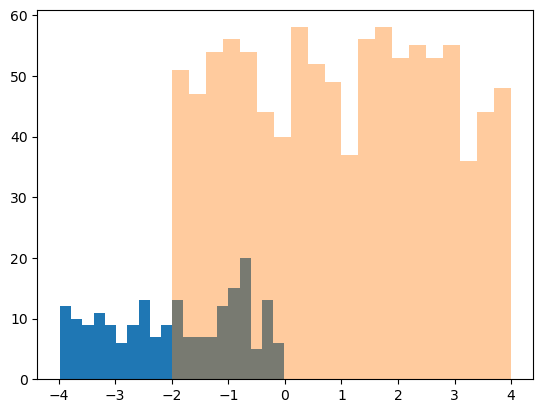

In [24]:
import matplotlib.pyplot as plt
plt.hist(data_exp[:, 1], bins=20)
plt.hist(data_obs[:, 1], bins = 20, alpha=0.4)


In [25]:
# Model training 

import GPy
import numpy as np

def ICM(X_E, X_O, T_E, T_O, Y_E, Y_O, r, ID, AD, rho):
    """
    Train and return two rank-2 ICMs
    Args:
    - X_E (numpy.ndarray): Baseline covariate in the experimental data.
    - X_O (numpy.ndarray): Baseline covariate in the observational data.
    - T_E (numpy.ndarray): Treatment indicator in the experimental data.
    - T_O (numpy.ndarray): Treatment indicator in the observational data.
    - Y_E (numpy.ndarray): Outcome in the experimental data.
    - Y_O (numpy.ndarray): Outcome in the observational data.
    - r (int): Rank of the model.
    - ID (int): input dim
    - AD (list): active dim
    - rho: trust hyperparameter

    Returns:
    GPy.models.GPRegression: Trained Gaussian Process Regression model using Intrinsic Coregionalized Model (ICM).

    Data Processing:
    - Split the variables into treated and control for both observational and experimental data.

    Model Training:
    - Intrinsic Coregionalized Model (ICM) with a Radial Basis Function (RBF) kernel is used for regression.
    - The model is trained using Gaussian Process Regression.

    Note:
    - The order of arranging data matters: Experimental control, Observational control, Experimental treated, Observational treated.
    - An indicator is added to the baseline covariate to represent the task (0 for experimental control, 1 for observational control, 2 for experimental treated, 3 for observational treated).
    """

    # Data preprocessing
    # Split the variables in treated and control 
    # Observational Data
    X0_obs = X_O[T_O==0] # baseline covariate in th control arm of the observational study
    X1_obs = X_O[T_O==1] # baseline covariate in th treatment arm of the observational study
    Y0_obs = Y_O[T_O==0] # outcomee in th control arm of the observational study
    Y1_obs = Y_O[T_O==1] # outcomee in th treatment arm of the observational study
    
    #Exoerimental data
    X0_exp = X_E[T_E==0] # baseline covariate in th control arm of the experimental study
    X1_exp = X_E[T_E==1] # baseline covariate in th treatment arm of the experimental study
    Y0_exp = Y_E[T_E==0] # outcomee in th control arm of the experimental study
    Y1_exp = Y_E[T_E==1] # outcomee in th treatment arm of the experimental study
    

    # The order we arrange the data matters
    # 1. Experimental control
    # 2. Observational control
    # 3. Experimental treated
    # 4. Observational treated
    # We also need to add an indicator to the baseline covariate indicating the task
    # i.e. 0 is for the experiemental control, 1 is for the observational control,
    # 2 is for the experiemental treated, 3 is for observational treated
    X0_exp = np.c_[X0_exp,np.ones(X0_exp.shape[0])*0] 
    X0_obs = np.c_[X0_obs,np.ones(X0_obs.shape[0])*1]
    X1_exp = np.c_[X1_exp,np.ones(X1_exp.shape[0])*0]
    X1_obs = np.c_[X1_obs,np.ones(X1_obs.shape[0])*1]

    # Put all the data on a single array 
    Y0 = np.r_[Y0_exp, Y0_obs]
    X0 = np.r_[X0_exp, X0_obs]
    Y1 = np.r_[Y1_exp, Y1_obs]
    X1 = np.r_[X1_exp, X1_obs]


    # model training
    
    # Define the kernel
    kern = GPy.kern.RBF(input_dim=ID, active_dims = AD)**GPy.kern.Coregionalize(input_dim = 1, output_dim = 2, rank=r)
    # Define the model
    m0 = GPy.models.GPRegression(X0,np.vstack(Y0),kern)
    ##############################################################
    # Put all your constraines here
    m0.mul.coregion.W[0,0:1].fix(1)
    m0.mul.coregion.W[0,1:].fix(0)
    m0.mul.coregion.W[1,0:1].fix(rho)
    m0.mul.coregion.W[1,1:].fix(np.sqrt(1-rho**2))
    m0.mul.coregion.kappa.fix([0.000000001, 0.000000001])
    #m0.mul.rbf.variance.constrain_bounded(0., 10.)
    
    ##############################################################
    

    # Optimize the model
    m0.optimize()

    # Define the kernel
    kern = GPy.kern.RBF(input_dim=ID, active_dims = AD)**GPy.kern.Coregionalize(input_dim = 1, output_dim = 2, rank=r)
    # Define the model
    m1 = GPy.models.GPRegression(X1,np.vstack(Y1),kern)
    ##############################################################
    # Put all your constraines here
    m1.mul.coregion.W[0,0:1].fix(1)
    m1.mul.coregion.W[0,1:].fix(0)
    m1.mul.coregion.W[1,0:1].fix(rho)
    m1.mul.coregion.W[1,1:].fix(np.sqrt(1-rho**2))
    m1.mul.coregion.kappa.fix([0.000000001, 0.000000001])
    #m1.mul.rbf.variance.constrain_bounded(0., 10.)

    ##############################################################
    # Optimize the model
    
    m1.optimize()

    return m0, m1

In [26]:
import numpy as np
def weighted_mean_squared_error(weight, t, y_true, y_pred0, y_pred1):
    # Ensure inputs are numpy arrays
    y_true = np.hstack(y_true)
    y_pred0 = np.hstack(y_pred0)
    y_pred1 = np.hstack(y_pred1)
    weight = np.hstack(weight)
    weighted_squared_diff = np.zeros(y_true.shape[0])
    weighted_squared_diff[t==0] = weight[t==0]*((y_true[t==0] - y_pred0[t==0])**2) 
    weighted_squared_diff[t==1] = weight[t==1]*((y_true[t==1] - y_pred1[t==1])**2)  
    wmse = np.mean(weighted_squared_diff)
        
    return wmse

In [30]:
# -------------------------------
# Imports and setup
# -------------------------------
import sys
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error


# -------------------------------
# Set seeds for reproducibility
# -------------------------------
seed_value = 1234
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)


data_full = np.r_[data_exp, data_obs]

# -------------------------------
# Logistic regression for trial participation
# -------------------------------
from sklearn import linear_model
logr = linear_model.LogisticRegression()
logr.fit(data_full[:,1].reshape(-1,1), data_full[:,0])
prob = logr.predict_proba(data_full[:,1].reshape(-1,1))
prob_part = prob[:,1]
data_full = np.c_[data_full, 1/prob_part]


# -------------------------------
# Rho tuning via cross-validation
# -------------------------------
from sklearn.model_selection import KFold

rho_values = np.round(np.arange(0, 1.05, 0.1), 1)
num_folds = 5
min_avg_wmse = float('inf')
best_rho = None
wmse_per_rho = {}

kf = KFold(n_splits=num_folds, shuffle=True)
for rho in rho_values:
    print(f"Rho: {rho}")
    avg_wmse = 0
    fold_num = 0
    wmse_per_fold = []
    for train_index, val_index in kf.split(data_full):
        train_data, val_data = data_full[train_index], data_full[val_index]
        val_data = val_data[val_data[:,0]==1]
        X_val, T_val, Y_val, w = val_data[:,1], val_data[:,2], val_data[:,3], val_data[:,4]

        m0, m1 = ICM(
            X_E=train_data[train_data[:,0]==1,1],
            X_O=train_data[train_data[:,0]==0,1],
            T_E=train_data[train_data[:,0]==1,2],
            T_O=train_data[train_data[:,0]==0,2],
            Y_E=train_data[train_data[:,0]==1,3],
            Y_O=train_data[train_data[:,0]==0,3],
            r=2, ID=1, AD=0, rho=rho
        )

        predY0_exp = m0.predict_noiseless(np.c_[np.vstack(val_data[:,1]), np.zeros(val_data[:,1].shape)])
        predY1_exp = m1.predict_noiseless(np.c_[np.vstack(val_data[:,1]), np.zeros(val_data[:,1].shape)])
        wmse = weighted_mean_squared_error(weight=w, t=T_val, y_true=Y_val, y_pred0=predY0_exp[0], y_pred1=predY1_exp[0])
        avg_wmse += wmse
        wmse_per_fold.append(wmse)

        print(f"Fold {fold_num + 1} WMSE: {wmse}")
        fold_num += 1

    avg_wmse /= num_folds
    print(f"Average WMSE for Rho {rho}: {avg_wmse}")
    wmse_per_rho[rho] = wmse_per_fold
    if avg_wmse < min_avg_wmse:
        min_avg_wmse = avg_wmse
        best_rho = rho

print(f"Best Rho: {best_rho}, Minimum Average WMSE: {min_avg_wmse}")
pd.DataFrame([best_rho], columns=['best_rho']).to_csv('sim8_best_rho.csv', index=False)



Rho: 0.0
Fold 1 WMSE: 4.230823420599431
Fold 2 WMSE: 3.9722445360506513
Fold 3 WMSE: 1.438668854581877
Fold 4 WMSE: 4.563696169498387
Fold 5 WMSE: 1.8924772597802977
Average WMSE for Rho 0.0: 3.2195820481021284
Rho: 0.1
Fold 1 WMSE: 3.8082550458026265
Fold 2 WMSE: 4.696521423947198
Fold 3 WMSE: 2.6513800947441597
Fold 4 WMSE: 2.4868406709115773
Fold 5 WMSE: 3.618051639453944
Average WMSE for Rho 0.1: 3.4522097749719007
Rho: 0.2
Fold 1 WMSE: 4.149613645043672
Fold 2 WMSE: 2.0360988569000926
Fold 3 WMSE: 3.0187900269428245
Fold 4 WMSE: 3.708936697557579
Fold 5 WMSE: 3.6770451744541686
Average WMSE for Rho 0.2: 3.3180968801796675
Rho: 0.3
Fold 1 WMSE: 2.357442952124623
Fold 2 WMSE: 3.394648601576038
Fold 3 WMSE: 5.262152075566954
Fold 4 WMSE: 4.356801912450102
Fold 5 WMSE: 1.5590980532923817
Average WMSE for Rho 0.3: 3.3860287190020193
Rho: 0.4
Fold 1 WMSE: 4.640206598227383
Fold 2 WMSE: 2.7001548606533863
Fold 3 WMSE: 2.7212952863691253
Fold 4 WMSE: 4.1499103124279
Fold 5 WMSE: 2.2552316

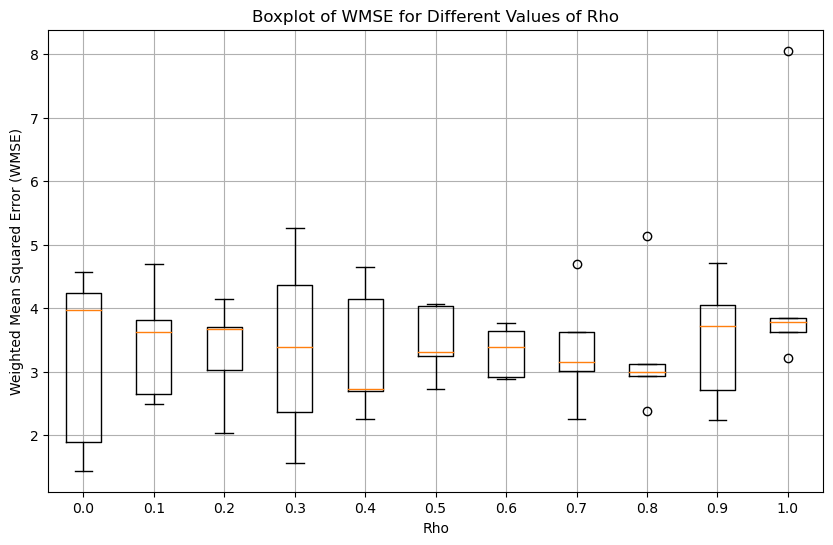

In [31]:
# Create a boxplot of wmse for each value of rho
plt.figure(figsize=(10, 6))
plt.boxplot(wmse_per_rho.values(), labels=wmse_per_rho.keys())
plt.title('Boxplot of WMSE for Different Values of Rho')
plt.xlabel('Rho')
plt.ylabel('Weighted Mean Squared Error (WMSE)')
plt.grid(True)
plt.show()

RMSE - ICMexp:  0.9276584270016524
RMSE - ICMobs:  1.6592068018595914


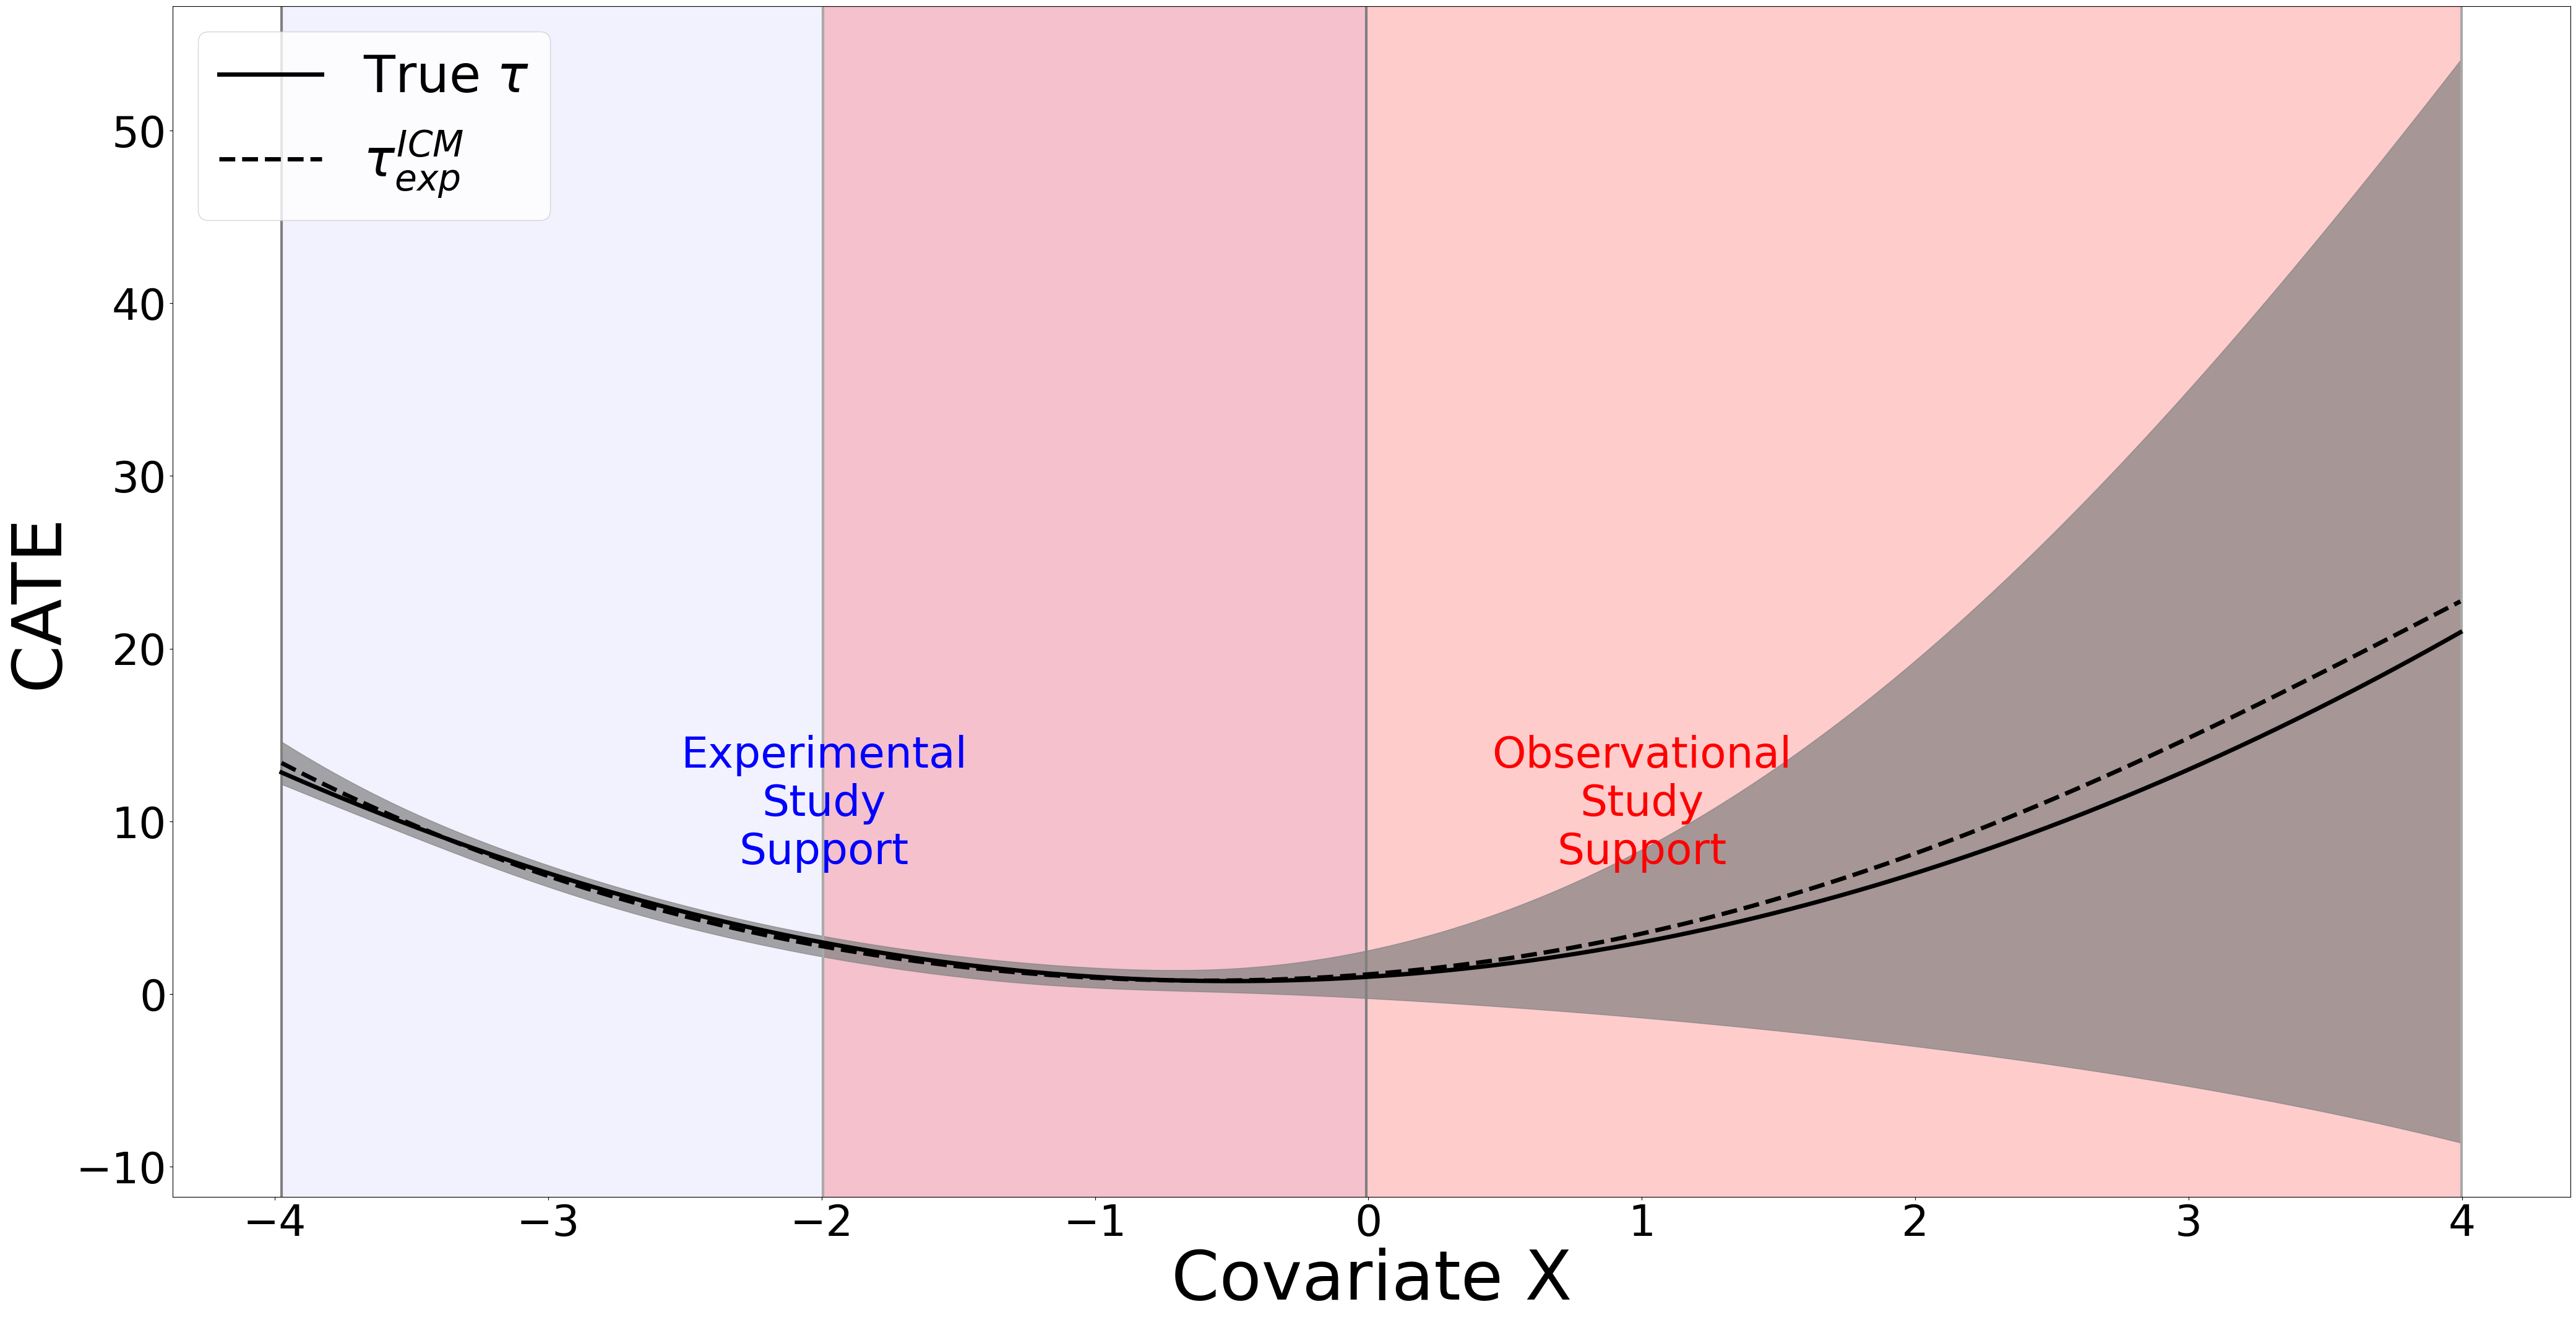

In [38]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.metrics import mean_squared_error
import numpy.random as nprand
import matplotlib.pyplot as plt
import pandas as pd

#best_rho = pd.read_csv('sim8_best_rho.csv').values[0]


# Train Models
m0, m1 = ICM(X_E = data_exp[:,1], X_O = data_obs[:,1], 
             T_E = data_exp[:,2], T_O = data_obs[:,2], 
             Y_E = data_exp[:,3], Y_O = data_obs[:,3],  
             r = 2, ID=1, AD=0, rho=best_rho)
# predictions
test_data = np.arange(np.min(np.r_[data_exp[:,1],data_obs[:,1]]),np.max(np.r_[data_exp[:,1],data_obs[:,1]]),0.01)
# predictions
predY0_exp = m0.predict_noiseless(np.c_[np.vstack(test_data),np.ones(test_data.shape[0])*0])
predY0_obs = m0.predict_noiseless(np.c_[np.vstack(test_data),np.ones(test_data.shape[0])*1])
predY1_exp = m1.predict_noiseless(np.c_[np.vstack(test_data),np.ones(test_data.shape[0])*0])
predY1_obs = m1.predict_noiseless(np.c_[np.vstack(test_data),np.ones(test_data.shape[0])*1])
predCATE_exp = predY1_exp[0] - predY0_exp[0]
varCATE_exp = predY1_exp[1] + predY0_exp[1]
predCATE_obs = predY1_obs[0] - predY0_obs[0]
varCATE_obs = predY1_obs[1] + predY0_obs[1]
# Compute confounding

confound2 = - predCATE_exp  +  predCATE_obs

# Evaluate predictions

# Ground truth
true_cate = 1+test_data+test_data**2
# Compute RMSE
from sklearn.metrics import mean_squared_error
print("RMSE - ICMexp: ", mean_squared_error(predCATE_exp, true_cate, squared=False))
print("RMSE - ICMobs: ", mean_squared_error(predCATE_obs, true_cate, squared=False))
# Plot prediction
import matplotlib.pyplot as plt
list_CATE_exp=zip(*sorted(zip(*(test_data,predCATE_exp))))
list_CATE=zip(*sorted(zip(*(test_data,true_cate))))
plt.figure(figsize=(50,25))
plt.axvline(x=np.min(data_exp[:,1]), c='grey', linewidth = 3.0)
plt.axvline(x=np.max(data_exp[:,1]), c='grey', linewidth = 3.0)
plt.axvline(x=np.min(data_obs[:,1]), c='darkgrey', linewidth = 3.0)
plt.axvline(x=np.max(data_obs[:,1]), c='darkgrey', linewidth = 3.0)
plt.axvspan(np.min(data_exp[:,1]), np.max(data_exp[:,1]), alpha=0.05, color='blue')
plt.axvspan(np.min(data_obs[:,1]), np.max(data_obs[:,1]), alpha=0.2, color='red')
plt.text(((np.max(data_exp[:,1]) + np.min(data_exp[:,1]))/2), 15, 'Experimental\nStudy\nSupport', verticalalignment='top', horizontalalignment='center', size=50, c = "blue")
plt.text(((np.max(data_obs[:,1]) + np.min(data_obs[:,1]))/2), 15, 'Observational\nStudy\nSupport', verticalalignment='top', horizontalalignment='center', size=50, c = "red")
plt.plot(*list_CATE, label = 'True $\\tau$', c='black', linewidth=5.0)
plt.plot(*list_CATE_exp, label = '$\\tau_{exp}^{ICM}$', c="black", linewidth=5.0, linestyle='dashed')
plt.fill_between(test_data, 
                 np.hstack(predCATE_exp-2*np.vstack(np.sqrt(varCATE_exp))), 
                 np.hstack(predCATE_exp+2*np.vstack(np.sqrt(varCATE_exp))),
                color = "grey", alpha=0.7)

plt.yticks(fontsize=50)
plt.xticks(fontsize=50)

plt.xlabel("Covariate X", fontsize=80)
plt.ylabel("CATE", fontsize=80)
plt.legend(fontsize=60, loc='upper left')

# Performance within the RCT support 

In [39]:
import pandas as pd
df_all = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/univariate/Simulation 8/datasets_sim8.csv")

In [40]:
df_all.head()

,S,X,A,Y,datasetNo
0,1.0,-1.093187,1.0,1.059032,1
1,1.0,-0.938575,0.0,-0.248602,1
2,1.0,-1.893287,0.0,1.340540,1
3,1.0,-1.006195,0.0,0.305885,1
4,1.0,-1.904948,0.0,2.176619,1


In [47]:
import sys
sys.path.append("/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__")

import numpy as np
import pandas as pd
import GPy
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge as ridge
from neurIPS.functions.data_simulation import data_simulation8
from neurIPS.functions.model_training import ICM

In [ ]:
import sys
sys.path.append("/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__")

import numpy as np
import pandas as pd
import GPy
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge as ridge
from neurIPS.functions.data_simulation import data_simulation8
from neurIPS.functions.model_training import ICM

# -------------------------------
# Utility functions
# -------------------------------
rmse = lambda x, y: np.sqrt(mean_squared_error(x, y))

linear_reg_parameter_pairs = [
    (ridge(), {'alpha': np.logspace(-7, 7, 8), 'tol': [1e-3]})
]

def get_best_model_from_gridcv(X, Y, reg_parameter_pairs, print_flag=False, verbose=0):
    val_errs = []
    models = []
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
    for reg, parameters in reg_parameter_pairs:
        if print_flag:
            print('Trying', str(reg)[:50])
        model = GridSearchCV(reg, parameters, cv=2, refit=True, verbose=verbose, n_jobs=10)
        model.fit(X, Y)
        val_errs.append(rmse(y_test, model.predict(x_test)))
        models.append(copy.deepcopy(model.best_estimator_))
    min_ind = val_errs.index(min(val_errs))
    if verbose != 0:
        print(str(models[min_ind]), 'val rmse:{}'.format(val_errs[min_ind]))
    return copy.deepcopy(models[min_ind])

# -------------------------------
# GP-based Kallus adjustment
# -------------------------------
def run_methodGP(X_rct, Y_rct, T_rct, X_obs, Y_obs, T_obs, X_eval):
    # GP on observational data
    kern = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    f0_gp = GPy.models.GPRegression(np.vstack(X_obs[T_obs==0]), np.vstack(Y_obs[T_obs==0]), kern)
    f0_gp.optimize()
    f1_gp = GPy.models.GPRegression(np.vstack(X_obs[T_obs==1]), np.vstack(Y_obs[T_obs==1]), kern)
    f1_gp.optimize()

    # Predict CATE components
    omega_rct_pred = f1_gp.predict(np.vstack(X_rct))[0] - f0_gp.predict(np.vstack(X_rct))[0]
    omega_obs_pred = f1_gp.predict(np.vstack(X_obs))[0] - f0_gp.predict(np.vstack(X_obs))[0]
    omega_eval_pred = f1_gp.predict(np.vstack(X_eval))[0] - f0_gp.predict(np.vstack(X_eval))[0]

    # Estimate residual eta on RCT
    prop_rct = np.mean(T_rct)
    def ite_adjusted_outcome(Y, T, _propensity, c=None):
        c = np.mean(Y) if c is None else c
        _ite = np.zeros(Y.shape)
        _ite[T==1] = (Y[T==1] - c) / _propensity
        _ite[T==0] = -(Y[T==0] - c) / (1-_propensity)
        return _ite

    cate_rct_est = ite_adjusted_outcome(Y_rct, T_rct, _propensity=prop_rct)
    eta_rct_est = np.vstack(cate_rct_est) - np.vstack(omega_rct_pred)

    # Fit linear model to eta
    best_eta_model = get_best_model_from_gridcv(X_rct.reshape(-1,1), eta_rct_est, linear_reg_parameter_pairs)
    
    return copy.deepcopy(best_eta_model), omega_obs_pred, omega_eval_pred

# -------------------------------
# Initialize arrays to store results
# -------------------------------
num_simulations = 100
test_data = np.round(np.arange(-2.0, 0.04, 0.04), 2).reshape(-1,1)

rmse_naiveGP_exp = np.zeros(num_simulations)
rmse_naiveGP_obs = np.zeros(num_simulations)
rmse_KallusGP = np.zeros(num_simulations)
rmse_ICM = np.zeros(num_simulations)

bias_naiveGP_exp = np.zeros(num_simulations)
bias_naiveGP_obs = np.zeros(num_simulations)
bias_KallusGP = np.zeros(num_simulations)
bias_ICM = np.zeros(num_simulations)

var_naiveGP_exp = np.zeros(num_simulations)
var_naiveGP_obs = np.zeros(num_simulations)
var_KallusGP = np.zeros(num_simulations)
var_ICM = np.zeros(num_simulations)

bias_naive_exp_df = pd.DataFrame(test_data)
bias_naive_obs_df = pd.DataFrame(test_data)
bias_kallus_df = pd.DataFrame(test_data)
bias_icm_df = pd.DataFrame(test_data)

all_data = []
best_rho = pd.read_csv('sim8_best_rho.csv').values[0][0]

# -------------------------------
# Simulation loop
# -------------------------------
for i in range(num_simulations):
    print(f"Simulation {i+1}")
    data_exp = df_all[(df_all["S"]==1) & (df_all["datasetNo"]==i+1)]
    data_obs = df_all[(df_all["S"]==0) & (df_all["datasetNo"]==i+1)]



    # Split by treatment group
    X0_obs, X1_obs = data_obs[data_obs["A"]==0]["X"], data_obs[data_obs["A"]==1]["X"]
    Y0_obs, Y1_obs = data_obs[data_obs["A"]==0]["Y"], data_obs[data_obs["A"]==1]["Y"]
    X0_exp, X1_exp = data_exp[data_exp["A"]==0]["X"], data_exp[data_exp["A"]==1]["X"]
    Y0_exp, Y1_exp = data_exp[data_exp["A"]==0]["Y"], data_exp[data_exp["A"]==1]["Y"]

    trueCATE = 1 + test_data + test_data**2

    # -------------------------------
    # Naive GP on observational data
    # -------------------------------
    kern = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    m0_obs = GPy.models.GPRegression(np.vstack(X0_obs), np.vstack(Y0_obs), kern)
    m0_obs.optimize()
    m1_obs = GPy.models.GPRegression(np.vstack(X1_obs), np.vstack(Y1_obs), kern)
    m1_obs.optimize()
    naiveCATE_obs = (m1_obs.predict(np.vstack(test_data))[0] - m0_obs.predict(np.vstack(test_data))[0]).flatten()

    # -------------------------------
    # Naive GP on experimental data
    # -------------------------------
    m0_exp = GPy.models.GPRegression(np.vstack(X0_exp), np.vstack(Y0_exp), kern)
    m0_exp.optimize()
    m1_exp = GPy.models.GPRegression(np.vstack(X1_exp), np.vstack(Y1_exp), kern)
    m1_exp.optimize()
    naiveCATE_exp = (m1_exp.predict(np.vstack(test_data))[0] - m0_exp.predict(np.vstack(test_data))[0]).flatten()

    # -------------------------------
    # Kallus GP
    # -------------------------------
    eta_model, omega_obs_pred, omega_eval_pred = run_methodGP(
        data_exp["X"].values, data_exp["Y"].values, data_exp["A"].values,
        data_obs["X"].values, data_obs["Y"].values, data_obs["A"].values,
        test_data
    )
    tau_pred = eta_model.predict(test_data.reshape(-1,1)) + omega_eval_pred

    # -------------------------------
    # ICM
    # -------------------------------
    m0_icm, m1_icm = ICM(X_E=data_exp["X"], X_O=data_obs["X"],
                          T_E=data_exp["A"], T_O=data_obs["A"],
                          Y_E=data_exp["Y"], Y_O=data_obs["Y"],
                          r=2, ID=1, AD=0, rho=best_rho)
    predCATE_icm = m1_icm.predict_noiseless(np.c_[np.vstack(test_data), np.zeros(test_data.shape[0])])[0] - \
                   m0_icm.predict_noiseless(np.c_[np.vstack(test_data), np.zeros(test_data.shape[0])])[0]

    # -------------------------------
    # Store metrics
    # -------------------------------
    rmse_naiveGP_exp[i] = rmse(naiveCATE_exp, trueCATE)
    rmse_naiveGP_obs[i] = rmse(naiveCATE_obs, trueCATE)
    rmse_KallusGP[i] = rmse(tau_pred, trueCATE)
    rmse_ICM[i] = rmse(predCATE_icm, trueCATE)

    bias_naiveGP_exp[i] = np.mean(naiveCATE_exp - trueCATE)
    bias_naiveGP_obs[i] = np.mean(naiveCATE_obs - trueCATE)
    bias_KallusGP[i] = np.mean(tau_pred - trueCATE)
    bias_ICM[i] = np.mean(predCATE_icm - trueCATE)

    var_naiveGP_exp[i] = np.var(naiveCATE_exp)
    var_naiveGP_obs[i] = np.var(naiveCATE_obs)
    var_KallusGP[i] = np.var(tau_pred)
    var_ICM[i] = np.var(predCATE_icm)

    



Simulation 1
Simulation 2
Simulation 3
Simulation 4
Simulation 5


 /Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Simulation 6
Simulation 7


 /Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Simulation 8
Simulation 9
Simulation 10
Simulation 11
Simulation 12


...

 /Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Simulation 93
Simulation 94


 /Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Simulation 95
Simulation 96
Simulation 97
Simulation 98
Simulation 99
Simulation 100


ValueError: No objects to concatenate

In [67]:
# -------------------------------
# Save results
# -------------------------------

in_sample_comparison_df = pd.DataFrame(np.c_[rmse_naiveGP_exp, rmse_naiveGP_obs, rmse_KallusGP, rmse_ICM,
                                                   bias_naiveGP_exp, bias_naiveGP_obs, bias_KallusGP, bias_ICM,
                                                   var_naiveGP_exp, var_naiveGP_obs, var_KallusGP, var_ICM], 
                                            columns=['RMSE_naiveGPexp','RMSE_naiveGPobs','RMSE_KallusGP','RMSE_ICM',
                                                     'bias_naiveGPexp','bias_naiveGPobs','bias_KallusGP','bias_ICM',
                                                     'var_naiveGPexp','var_naiveGPobs','var_KallusGP','var_ICM'])
in_sample_comparison_df.to_csv("in_sample_comparison_results.csv", index = False)

In [68]:
in_sample_comparison_df.head()

,RMSE_naiveGPexp,RMSE_naiveGPobs,RMSE_KallusGP,RMSE_ICM,bias_naiveGPexp,bias_naiveGPobs,bias_KallusGP,bias_ICM,var_naiveGPexp,var_naiveGPobs,var_KallusGP,var_ICM
0,39.648077,67.135124,1.394339,0.304079,-38.282025,-66.837689,0.725877,0.183309,94.557743,32.543552,0.292391,0.821775
1,5.613566,114.694108,2.860488,0.094149,-2.946483,-113.098526,1.038408,-0.067570,17.393654,342.812135,7.104790,0.525926
2,10.057539,26.696600,5.282706,0.168983,-7.489985,-0.980678,-0.401279,-0.044675,37.962992,678.387094,27.626922,0.579911
3,6.160267,7.734639,2.903617,0.275081,5.359687,-0.757866,0.756654,0.046560,5.627774,52.630508,8.273653,0.702422
4,3.061174,321.033120,0.903277,0.255313,2.930690,-320.875694,0.403225,0.198210,0.065800,90.016439,0.747914,0.269492


# Out of sample performance

In [1]:
import sys
sys.path.append("/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__")

import numpy as np
import pandas as pd
import GPy
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge as ridge
from neurIPS.functions.data_simulation import data_simulation8
from neurIPS.functions.model_training import ICM

# -------------------------------
# Utility functions
# -------------------------------
rmse = lambda x, y: np.sqrt(mean_squared_error(x, y))

linear_reg_parameter_pairs = [
    (ridge(), {'alpha': np.logspace(-7, 7, 8), 'tol': [1e-3]})
]

def get_best_model_from_gridcv(X, Y, reg_parameter_pairs, print_flag=False, verbose=0):
    val_errs = []
    models = []
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
    for reg, parameters in reg_parameter_pairs:
        if print_flag:
            print('Trying', str(reg)[:50])
        model = GridSearchCV(reg, parameters, cv=2, refit=True, verbose=verbose, n_jobs=10)
        model.fit(X, Y)
        val_errs.append(rmse(y_test, model.predict(x_test)))
        models.append(copy.deepcopy(model.best_estimator_))
    min_ind = val_errs.index(min(val_errs))
    if verbose != 0:
        print(str(models[min_ind]), 'val rmse:{}'.format(val_errs[min_ind]))
    return copy.deepcopy(models[min_ind])

# -------------------------------
# GP-based Kallus adjustment
# -------------------------------
def run_methodGP(X_rct, Y_rct, T_rct, X_obs, Y_obs, T_obs, X_eval):
    # GP on observational data
    kern = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    f0_gp = GPy.models.GPRegression(np.vstack(X_obs[T_obs==0]), np.vstack(Y_obs[T_obs==0]), kern)
    f0_gp.optimize()
    f1_gp = GPy.models.GPRegression(np.vstack(X_obs[T_obs==1]), np.vstack(Y_obs[T_obs==1]), kern)
    f1_gp.optimize()

    # Predict CATE components
    omega_rct_pred = f1_gp.predict(np.vstack(X_rct))[0] - f0_gp.predict(np.vstack(X_rct))[0]
    omega_obs_pred = f1_gp.predict(np.vstack(X_obs))[0] - f0_gp.predict(np.vstack(X_obs))[0]
    omega_eval_pred = f1_gp.predict(np.vstack(X_eval))[0] - f0_gp.predict(np.vstack(X_eval))[0]

    # Estimate residual eta on RCT
    prop_rct = np.mean(T_rct)
    def ite_adjusted_outcome(Y, T, _propensity, c=None):
        c = np.mean(Y) if c is None else c
        _ite = np.zeros(Y.shape)
        _ite[T==1] = (Y[T==1] - c) / _propensity
        _ite[T==0] = -(Y[T==0] - c) / (1-_propensity)
        return _ite

    cate_rct_est = ite_adjusted_outcome(Y_rct, T_rct, _propensity=prop_rct)
    eta_rct_est = np.vstack(cate_rct_est) - np.vstack(omega_rct_pred)

    # Fit linear model to eta
    best_eta_model = get_best_model_from_gridcv(X_rct.reshape(-1,1), eta_rct_est, linear_reg_parameter_pairs)
    
    return copy.deepcopy(best_eta_model), omega_obs_pred, omega_eval_pred

# -------------------------------
# Initialize arrays to store results
# -------------------------------
num_simulations = 100
test_data = np.round(np.arange(0.0, 2.04, 0.04), 2).reshape(-1,1)

rmse_naiveGP_exp = np.zeros(num_simulations)
rmse_naiveGP_obs = np.zeros(num_simulations)
rmse_KallusGP = np.zeros(num_simulations)
rmse_ICM = np.zeros(num_simulations)

bias_naiveGP_exp = np.zeros(num_simulations)
bias_naiveGP_obs = np.zeros(num_simulations)
bias_KallusGP = np.zeros(num_simulations)
bias_ICM = np.zeros(num_simulations)

var_naiveGP_exp = np.zeros(num_simulations)
var_naiveGP_obs = np.zeros(num_simulations)
var_KallusGP = np.zeros(num_simulations)
var_ICM = np.zeros(num_simulations)

bias_naive_exp_df = pd.DataFrame(test_data)
bias_naive_obs_df = pd.DataFrame(test_data)
bias_kallus_df = pd.DataFrame(test_data)
bias_icm_df = pd.DataFrame(test_data)

best_rho = pd.read_csv('sim8_best_rho.csv').values[0][0]
import pandas as pd
df_all = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/univariate/Simulation 8/datasets_sim8.csv")

# -------------------------------
# Simulation loop
# -------------------------------
for i in range(num_simulations):
    print(f"Simulation {i+1}")
    data_exp = df_all[(df_all["S"]==1) & (df_all["datasetNo"]==i+1)]
    data_obs = df_all[(df_all["S"]==0) & (df_all["datasetNo"]==i+1)]



    # Split by treatment group
    X0_obs, X1_obs = data_obs[data_obs["A"]==0]["X"], data_obs[data_obs["A"]==1]["X"]
    Y0_obs, Y1_obs = data_obs[data_obs["A"]==0]["Y"], data_obs[data_obs["A"]==1]["Y"]
    X0_exp, X1_exp = data_exp[data_exp["A"]==0]["X"], data_exp[data_exp["A"]==1]["X"]
    Y0_exp, Y1_exp = data_exp[data_exp["A"]==0]["Y"], data_exp[data_exp["A"]==1]["Y"]

    trueCATE = 1 + test_data + test_data**2

    # -------------------------------
    # Naive GP on observational data
    # -------------------------------
    kern = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    m0_obs = GPy.models.GPRegression(np.vstack(X0_obs), np.vstack(Y0_obs), kern)
    m0_obs.optimize()
    m1_obs = GPy.models.GPRegression(np.vstack(X1_obs), np.vstack(Y1_obs), kern)
    m1_obs.optimize()
    naiveCATE_obs = (m1_obs.predict(np.vstack(test_data))[0] - m0_obs.predict(np.vstack(test_data))[0]).flatten()

    # -------------------------------
    # Naive GP on experimental data
    # -------------------------------
    m0_exp = GPy.models.GPRegression(np.vstack(X0_exp), np.vstack(Y0_exp), kern)
    m0_exp.optimize()
    m1_exp = GPy.models.GPRegression(np.vstack(X1_exp), np.vstack(Y1_exp), kern)
    m1_exp.optimize()
    naiveCATE_exp = (m1_exp.predict(np.vstack(test_data))[0] - m0_exp.predict(np.vstack(test_data))[0]).flatten()

    # -------------------------------
    # Kallus GP
    # -------------------------------
    eta_model, omega_obs_pred, omega_eval_pred = run_methodGP(
        data_exp["X"].values, data_exp["Y"].values, data_exp["A"].values,
        data_obs["X"].values, data_obs["Y"].values, data_obs["A"].values,
        test_data
    )
    tau_pred = eta_model.predict(test_data.reshape(-1,1)) + omega_eval_pred

    # -------------------------------
    # ICM
    # -------------------------------
    m0_icm, m1_icm = ICM(X_E=data_exp["X"], X_O=data_obs["X"],
                          T_E=data_exp["A"], T_O=data_obs["A"],
                          Y_E=data_exp["Y"], Y_O=data_obs["Y"],
                          r=2, ID=1, AD=0, rho=best_rho)
    predCATE_icm = m1_icm.predict_noiseless(np.c_[np.vstack(test_data), np.zeros(test_data.shape[0])])[0] - \
                   m0_icm.predict_noiseless(np.c_[np.vstack(test_data), np.zeros(test_data.shape[0])])[0]

    # -------------------------------
    # Store metrics
    # -------------------------------
    rmse_naiveGP_exp[i] = rmse(naiveCATE_exp, trueCATE)
    rmse_naiveGP_obs[i] = rmse(naiveCATE_obs, trueCATE)
    rmse_KallusGP[i] = rmse(tau_pred, trueCATE)
    rmse_ICM[i] = rmse(predCATE_icm, trueCATE)

    bias_naiveGP_exp[i] = np.mean(naiveCATE_exp - trueCATE)
    bias_naiveGP_obs[i] = np.mean(naiveCATE_obs - trueCATE)
    bias_KallusGP[i] = np.mean(tau_pred - trueCATE)
    bias_ICM[i] = np.mean(predCATE_icm - trueCATE)

    var_naiveGP_exp[i] = np.var(naiveCATE_exp)
    var_naiveGP_obs[i] = np.var(naiveCATE_obs)
    var_KallusGP[i] = np.var(tau_pred)
    var_ICM[i] = np.var(predCATE_icm)

    



Simulation 1
Simulation 2
Simulation 3
Simulation 4
Simulation 5


 /Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Simulation 6
Simulation 7


 /Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Simulation 8
Simulation 9
Simulation 10
Simulation 11
Simulation 12


...

Simulation 88
Simulation 89
Simulation 90
Simulation 91
Simulation 92


 /Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Simulation 93
Simulation 94


 /Users/evangelosdimitriou/anaconda3/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Simulation 95
Simulation 96
Simulation 97
Simulation 98
Simulation 99
Simulation 100


In [2]:
# -------------------------------
# Save results
# -------------------------------

out_of_sample_comparison_df = pd.DataFrame(np.c_[rmse_naiveGP_exp, rmse_naiveGP_obs, rmse_KallusGP, rmse_ICM,
                                                   bias_naiveGP_exp, bias_naiveGP_obs, bias_KallusGP, bias_ICM,
                                                   var_naiveGP_exp, var_naiveGP_obs, var_KallusGP, var_ICM], 
                                            columns=['RMSE_naiveGPexp','RMSE_naiveGPobs','RMSE_KallusGP','RMSE_ICM',
                                                     'bias_naiveGPexp','bias_naiveGPobs','bias_KallusGP','bias_ICM',
                                                     'var_naiveGPexp','var_naiveGPobs','var_KallusGP','var_ICM'])
out_of_sample_comparison_df.to_csv("out_of_sample_comparison_results.csv", index = False)